<a href="https://colab.research.google.com/github/SofiaAlbyt/NM/blob/main/%D0%9A%D0%BE%D0%BF%D1%96%D1%8F_%D0%B7%D0%B0%D0%BF%D0%B8%D1%81%D0%BD%D0%B8%D0%BA%D0%B0_%22%D0%9B%D0%A0_10_%D0%90%D0%BB%D1%8C%D0%B1%D0%B8%D1%82_%D0%A1_%D0%A1_%D0%B21__ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

f'(x) = -4*sin(4*x) - 1
f''(x) = -16*cos(4*x)
f'''(x) = 64*sin(4*x)
f''''(x) = 256*cos(4*x)
f(0) = 2.0
T(x) = -8.0*x**2 - 1.0*x + 2.0


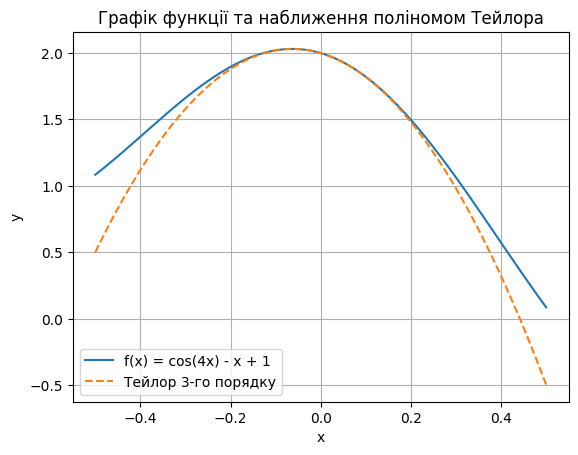

In [ ]:
# Лабораторна робота 10
# Наближення функцій багаточленом Тейлора
# Варіант 1

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Задаємо символьну змінну x та функцію f(x)
x = sp.symbols('x')
f = sp.cos(4*x) - x + 1

# Знаходимо перші чотири похідні
f1 = sp.diff(f, x)
f2 = sp.diff(f1, x)
f3 = sp.diff(f2, x)
f4 = sp.diff(f3, x)

# Виводимо похідні
print("f'(x) =", f1)
print("f''(x) =", f2)
print("f'''(x) =", f3)
print("f''''(x) =", f4)

# Точка розкладу
x0 = 0

# Значення функції та її похідних у точці x=0
f_x0 = f.subs(x, x0).evalf()
f1_x0 = f1.subs(x, x0).evalf()
f2_x0 = f2.subs(x, x0).evalf()
f3_x0 = f3.subs(x, x0).evalf()

# Поліном Тейлора 3-го порядку
T = (
    f_x0
    + f1_x0 * (x - x0)
    + (f2_x0 / 2) * (x - x0)**2
    + (f3_x0 / 6) * (x - x0)**3
)

T = sp.expand(T)

# Виводимо значення
print("f(0) =", round(float(f_x0), 3))
print("T(x) =", T.evalf())

# Будуємо графіки
x_vals = np.linspace(-0.5, 0.5, 1000)

f_vals = np.array([f.subs(x, xi).evalf() for xi in x_vals])
T_vals = np.array([T.subs(x, xi).evalf() for xi in x_vals])

fig, ax = plt.subplots()

ax.plot(x_vals, f_vals, label='f(x) = cos(4x) - x + 1')
ax.plot(x_vals, T_vals, label='Тейлор 3-го порядку', linestyle='--')

ax.legend()
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Графік функції та наближення поліномом Тейлора")

plt.grid(True)
plt.show()

Перша похідна f'(x): -4*sin(4*x) - 1
Друга похідна f''(x): -16*cos(4*x)
Третя похідна f'''(x): 64*sin(4*x)
Значення функції в точці x0=0: 2.0


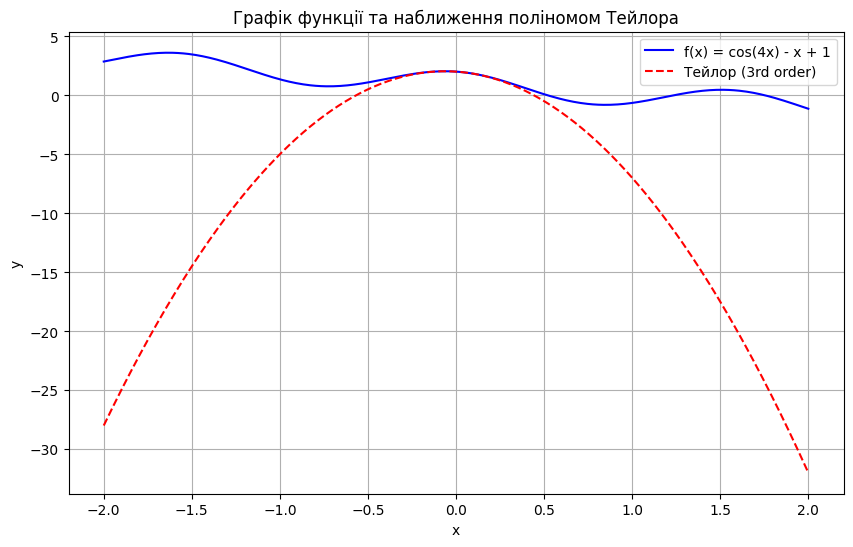

In [ ]:
# Варіант 2

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Задаємо символьну змінну x
x_sym = sp.symbols('x')

# Функція з варіанту
f = sp.cos(4 * x_sym) - x_sym + 1

# Обчислюємо перші три похідні
f_1 = sp.diff(f, x_sym)
f_2 = sp.diff(f_1, x_sym)
f_3 = sp.diff(f_2, x_sym)

# Виводимо похідні
print("Перша похідна f'(x):", f_1)
print("Друга похідна f''(x):", f_2)
print("Третя похідна f'''(x):", f_3)

# Компілюємо функції SymPy у функції Python
f_func = sp.lambdify(x_sym, f, 'numpy')
f_1_func = sp.lambdify(x_sym, f_1, 'numpy')
f_2_func = sp.lambdify(x_sym, f_2, 'numpy')
f_3_func = sp.lambdify(x_sym, f_3, 'numpy')

# Точка розкладу
x0 = 0

# Значення функції в точці x0
f_x0 = f_func(x0)

# Виведення значення
print(f"Значення функції в точці x0={x0}: {f_x0}")

# Діапазон значень x
x = np.linspace(-2, 2, 400)

# Значення функції
f_x = f_func(x)

# Поліном Тейлора 3-го порядку
taylor_x = (
    f_func(x0)
    + f_1_func(x0) * x
    + (f_2_func(x0) * x**2) / 2
    + (f_3_func(x0) * x**3) / 6
)

# Побудова графіків
plt.figure(figsize=(10, 6))

plt.plot(
    x,
    f_x,
    label='f(x) = cos(4x) - x + 1',
    color='blue')

plt.plot(
    x,
    taylor_x,
    label='Тейлор (3rd order)',
    color='red',
    linestyle='--')

plt.legend()

plt.title('Графік функції та наближення поліномом Тейлора')
plt.xlabel('x')
plt.ylabel('y')

plt.grid()

plt.show()

Taylor polynomial =
          15            14             13           12             11
0.000162 x  - 0.002435 x  - 0.0005669 x  + 0.03416 x  + 0.0007897 x 
           10             9         8             7         6
 - 0.2884 x  - 0.0005568 x + 1.625 x + 0.0002088 x - 5.689 x
              5         4             3     2
 - 3.986e-05 x + 10.67 x + 3.322e-06 x - 8 x - 1 x + 2


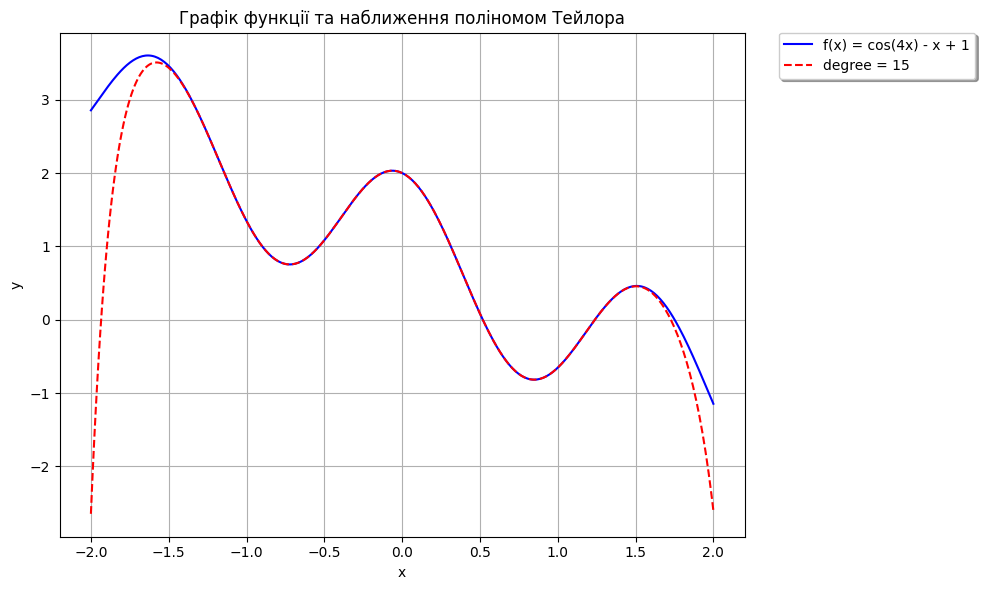

In [ ]:
# Побудова полінома Тейлора за допомогою approximate_taylor_polynomial

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial

# Задана функція
def f(x):
    return np.cos(4 * x) - x + 1

# Діапазон значень x
x = np.linspace(-2.0, 2.0, num=400)

# Побудова графіка функції
plt.figure(figsize=(10, 6))

plt.plot(
    x,
    f(x),
    label="f(x) = cos(4x) - x + 1",
    color='blue')

# Степінь полінома Тейлора
degree = 15

# Побудова полінома Тейлора
taylor = approximate_taylor_polynomial(f, 0, degree, 1)

# Виведення полінома
print('Taylor polynomial =')
print(taylor)

# Графік полінома Тейлора
plt.plot(
    x,
    taylor(x),
    label=f"degree = {degree}",
    color='red',
    linestyle='--')

# Оформлення
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0,
    shadow=True)

plt.xlabel("x")
plt.ylabel("y")

plt.title("Графік функції та наближення поліномом Тейлора")

plt.tight_layout()
plt.grid()

plt.show()

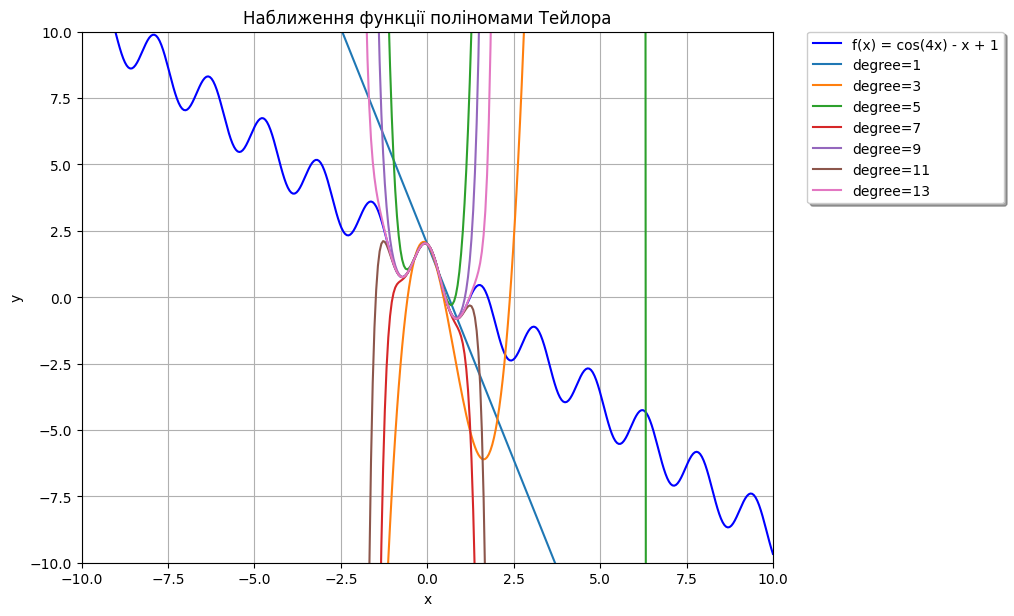

In [ ]:


import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import approximate_taylor_polynomial

# Задана функція
def f(x):
    return np.cos(4 * x) - x + 1

# Діапазон значень x
x = np.linspace(-10.0, 10.0, num=400)

# Побудова графіка функції
plt.figure(figsize=(10, 6))

plt.plot(
    x,
    f(x),
    label="f(x) = cos(4x) - x + 1",
    color='blue')

# Побудова поліномів Тейлора різних степенів
for degree in np.arange(1, 15, step=2):

    taylor_poly = approximate_taylor_polynomial(
        f,
        0,
        degree,
        1,
        order=degree + 2)

    plt.plot(
        x,
        taylor_poly(x),
        label=f"degree={degree}")

# Оформлення
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.0,
    shadow=True)

plt.tight_layout()

plt.axis([-10, 10, -10, 10])

plt.xlabel("x")
plt.ylabel("y")

plt.title("Наближення функції поліномами Тейлора")

plt.grid()

plt.show()